# FINER Instrument Walkthrough

This notebook demonstrates how to use the AtLAST Sensitivity Calculator with the FINER (Far-Infrared Nebular Emission Receiver) instrument. FINER is a wideband heterodyne receiver designed for the LMT telescope.

## FINER Specifications

- **Frequency Range**: 120-210, 210-360 GHz
- **Receiver Temperature**:    
\begin{equation} 
T_{rx} = \left\{ \begin{array}{rcl}
            45\,\textrm{K} & \textrm{for} & 120<\nu<210\,\textrm{GHz} \\ 
            75\,\textrm{K} & \textrm{for} & 210<\nu<360\,\textrm{GHz} 
            \end{array}\right. \nonumber
            \end{equation}
- **Type**: Heterodyne receiver
- **Purpose**: High-frequency spectroscopic observations
- **Instrument Webpage**: [FINER website](https://finerreceiver.github.io/)
- **Instrument Reference**: [Tamura et al. 2024](https://arxiv.org/abs/2406.07975)

This walkthrough will guide you through:
1. Setting up the calculator with FINER parameters
2. Demonstration of the typical calculator usage
3. Ensuring correct instrument selection
4. Visualising frequency coverage
5. Evaluating atmospheric conditions
6. Calculating system performance metrics

## Setup and Imports

First, we import the necessary modules and initialise the calculator using the CalculatorFactory.

In [1]:
# Import utilities
import numpy as np
import astropy.units as u

# Import Sensitivity Calculator
from atlast_sc.factory import CalculatorFactory


# Import Plotting routines
import matplotlib.pyplot as plt
# Set up plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

Next, because FINER has a low frequency and high frequency array, lets setup an array of frequencies that combines these two ranges for derivations through the notebook

In [2]:
# Create a frequency array spanning FINER's specific frequency ranges for plotting
frequencies = np.linspace(120, 360, 300)


## Quick Demonstration of the Calculator Usage

Here we show a quick demonstration of how the typical user will interact with the calculator in the FINER parameter space.

### Initialise the Calculator with FINER Parameters

We'll initialise the calculator with observation parameters that fall within FINER's frequency range and spectral resolution capabilities. The native spectral resolution of FINER is 88 kHz, so for lower spectral resolutions, we assume smoothing.

By setting FINER appropriate observing frequency and spectral channel bandwidth, the AtLAST sensitivity calculator will automatically select the appropriate instrument based on the observing frequency and single channel bandwidth.

In [27]:
# Create calculator instance using CalculatorFactory
calculator = CalculatorFactory().calculator

# Set observation parameters for FINER
calculator.user_input.obs_freq = 230.0 * u.GHz  # within FINER's range (120-210 or 210-360 GHz)
calculator.user_input.weather = 25.0  # percentile water vapour (see documentation for conversion to mm)
calculator.user_input.bandwidth = 100.0 * u.kHz  # near the spectral resolution limit of the instrument (88 kHz)
calculator.user_input.t_int = 30.0 * u.min  # on source time only, no calibration time added

Instrument has been changed from Default to Finer.


The output above shows that, given the inputs, the code has already chosen FINER as a suitable instrument for this calculation. To show the full list of parameters set for the initial calculations, we can ask the calculator to 'show' the full list of inputs available. Those not explicitly set above are passed their default settings.

In [28]:
print(f"Calculator initialised with the following parameters:")
calculator.user_input.show()

Calculator initialised with the following parameters:
bandwidth: 100.0 kHz
elevation: 45.0 deg
n_pol: 2.0
obs_freq: 230.0 GHz
sensitivity: 3.0 mJy
t_int: 30.0 min
weather: 25.0


### Calculating the Sensitivity or Observing Time for an Observation

Given these inputs we can then calculate the sensitivity reached in a 30 minute observation at an observing frequency of 345 GHz and spectral resolution of 100 kHz.

In [29]:
sens = calculator.calculate_sensitivity()
print(f'RMS sensitivity per channel: {sens}')

RMS sensitivity per channel: 11.864070454953188 mJy


Alternatively we can calculate the on source observing time to reach a given sensitivity.

In [30]:
calculator.user_input.sensitivity = 12*u.mJy
obs_time = calculator.calculate_t_integration()
print(f'On source observing time required: {obs_time}')

On source observing time required: 29.324201616686057 min


This is all that is needed for the typical user. The following steps of this notebook demonstrate the validation of the instrument and then the details of the sensitivity calculation for SEPIA.

## Ensuring Correct Instrument Selection

The calculator provides validation to ensure that your observing parameters (frequency and bandwidth) are compatible with the chosen instrument. This validation ensures your calculations are internally consistent with your expectations. If the parameters don't match, it raises an `InstrumentNotApplicableException` and suggests ways of setting a valid calculation.

### Why This Validation is Important

This validation prevents you from accidentally using an instrument with parameters outside its valid ranges, which would lead to incorrect sensitivity calculations. The error message helps you either:
- Adjust your parameters to fit the desired instrument, or
- Choose an instrument that matches your observing requirements

### Checking the Selected Instrument

Let's verify which instrument was automatically selected for our observation frequency:

In [5]:
# Check which instrument was automatically selected
print(f"Automatically selected instrument: {calculator.chosen_instrument}")

Automatically selected instrument: Finer


### Demonstrating Instrument Validation

Let's demonstrate how the instrument validation works. We'll first try to set FINER with incompatible parameters to see the validation in action, then show the correct approach.

In [6]:
# First, let's temporarily set incompatible parameters (bandwidth too large for FINER)
calculator.user_input.bandwidth = 1.0 * u.GHz  # outside FINER's range (max 180 MHz)

# This will raise an exception because our bandwidth doesn't fit FINER's ranges
try:
    calculator.chosen_instrument = 'FINER'
    print("Instrument set successfully")
except Exception as e:
    print(f"Cannot set to FINER: {type(e).__name__}")
    print(f"Reason: {str(e)}")

Instrument has been changed from Finer to Tifuun.
Cannot set to FINER: InstrumentNotApplicableException
Reason: Specified observing frequency and/or bandwidth values do not correspond to the chosen instrument 'Finer' ranges. Change the observing frequency and/or bandwidth values to use this instrument or choose another instrument. The set of parameters provided corresponds to other instrument/s, e.g. 'Tifuun'. To check the frequency and bandwidth ranges of the installed instruments type calculator.list_instruments().


Knowing that the setup is wrong, the above error statement is expected. Now lets reset the observing bandwidth to something that is achievable with FINER, and then show that that change has been applied.

In [7]:
# Reset to compatible bandwidth
calculator.user_input.bandwidth = 100.0 * u.kHz  # back within FINER's range
calculator.user_input.show()
print(f"Calculations will now be performed using: {calculator.chosen_instrument}")

Instrument has been changed from Tifuun to Finer.
bandwidth: 100.0 kHz
elevation: 45.0 deg
n_pol: 2.0
obs_freq: 230.0 GHz
sensitivity: 3.0 mJy
t_int: 100.0 s
weather: 25.0
Calculations will now be performed using: Finer


In the range of frequencies from 272 to 360 GHz, both FINER and SEPIA are valid instruments. The calculator automatically picks SEPIA for this range and so if FINER is desired, this needs to be explicitly requested.

In [58]:
calculator.user_input.obs_freq = 300*u.GHz # Both FINER and SEPIA are valid, but SEPIA is chosen.
calculator.chosen_instrument = 'FINER' # Force the use of FINER

Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.


## Visualise the inputs to the sensitivity calculation as a function of Frequency

Let's visualise how various parameters change as a function of frequency across the FINER bands. First, because FINER has a low frequency and high frequency array, lets setup an array of frequencies that combines these two ranges for derivations through the notebook

In [8]:
# Create a frequency array spanning FINER's specific frequency ranges for plotting
frequencies = np.linspace(120, 360, 300)

Because the calculator re-calculates on each parameter change, and there are a lot of calculations being done in this notebook, there is a single loop here which calculates all of the parameters we're exploring in the rest of the notebook. This includes:

* Atmospheric transmission (transmission)
* Receiver temperature (T_rx)
* System temperature (T_sys)
* Ambient temperature (T_amb)
* System Equivalent Flux Density (SEFD)
* Sensitivity

Expect this loop to take around 5 minutes.

N.B. As SEPIA is automatically selected for observing frequencies between 272 and 376 GHz, we need to ensure FINER is re-chosen after each change in frequency.

In [59]:
# expose the FINER instrument module in order to pull out the temperatures used in the calculations
finer_instrument = calculator._param_setup.chosen_instrument

# initialise empty lists to store the calculated parameters
transmission = []
t_rx_values = []
t_sky_contribution = []
t_amb_contribution = []
sefd_values = []
sensitivity = []


# looping over the frequency ranges covered by FINER
for freq in frequencies:
    # Set the observing frequency for this loop iteration, which triggers a re-calculation
    calculator.user_input.obs_freq = freq * u.GHz
    # Ensure FINER is the chosen instrument
    calculator.chosen_instrument = 'FINER'

    # extract atmospheric transmission from the calculator, and add it to the list
    transmission.append(calculator.derived_parameters.transmittance)

    # extract receiver temperature from the calculator, and add it to the list
    t_rx = finer_instrument.calculate_receiver_temp(calculator.user_input.obs_freq)
    t_rx_values.append(t_rx)

    # extract sky and ambient temperatures from the calculator, and add them to the lists
    t_sky_contribution.append(calculator.derived_parameters.T_sky.value)
    t_amb_contribution.append(calculator.telescope_and_environment.T_amb.value)

    # extract SEFD from the calculator, and add it to the list
    sefd_values.append(calculator.derived_parameters.sefd.to("Jy").value)

    # extract sensitivity from the calculator, and add it to the list
    sensitivity.append(calculator.calculate_sensitivity())

Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.
Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.
Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.
Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.
Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.
Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.
Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.
Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.
Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.
Instrument has been changed from Finer to Sepia.
Instrument has been changed from Sepia to Finer.
Instrument has been 

With all of those parameters derived, the following describes how they're used in the calculator, and we plot their values over the operational frequency ranges of FINER.

### Atmospheric Transmission

To show how atmospheric transmission varies, we plot the transmission as a function of frequency across the FINER operational frequency ranges. This is important for understanding how the sensitivity of the instrument changes with frequency.  The atmospheric transmission is calculated using the am code.

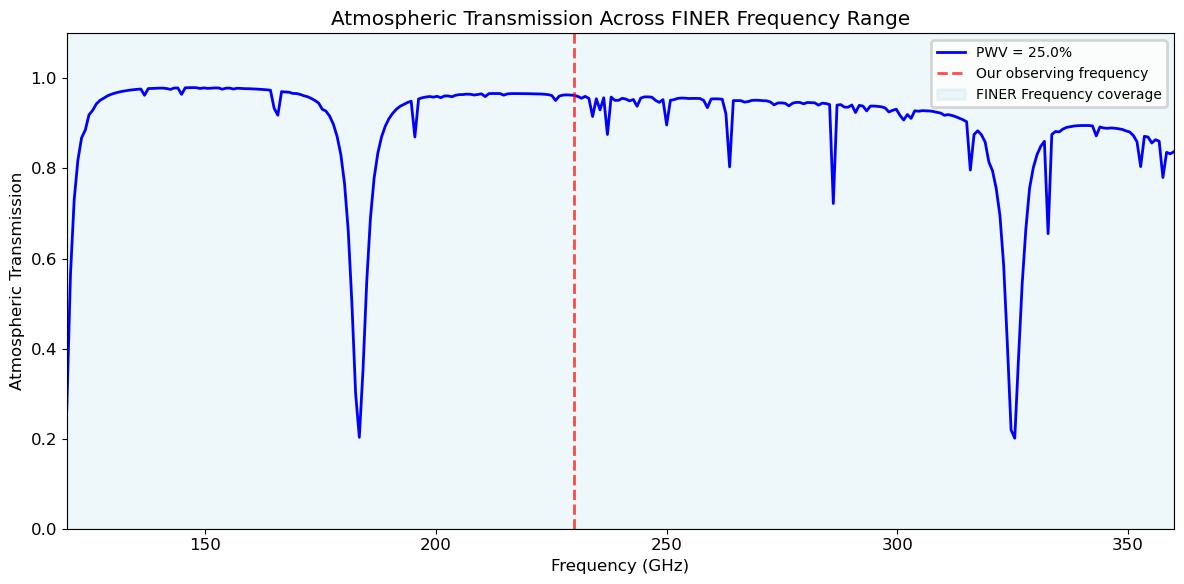

In [ ]:
# Reset to our primary observing frequency
calculator.user_input.obs_freq = 230.0*u.GHz

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# plot atmospheric transmission over the FINER operational frequency ranges
ax.plot(frequencies, transmission, 'b-', linewidth=2, label=f'Percentile water column  = {calculator.user_input.weather}%')
# draw a vertical line at our observing frequency (dashed)
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
#draw a box to highlight the operational frequencies of the FINER receiver
ax.axvspan(frequencies[0],frequencies[-1], color='lightblue', alpha=0.2, label='FINER Frequency coverage')

# label the plot
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Atmospheric Transmission')
ax.set_title('Atmospheric Transmission Across FINER Frequency Range')
ax.legend()
ax.set_ylim([0, 1.1])
plt.tight_layout()
plt.show()

## Receiver Temperature Calculation

FINER's receiver temperature changes between the two arrays, as shown below.

* T_rx = 45 K for the low frequency array (120-210 GHz)
* T_rx = 75 K for the high frequency array (210-360 GHz)

We can show how the receiver temperatures are set for the two arrays, which is important for understanding the sensitivity of the instrument. The receiver temperature is a key factor in determining the instrument's sensitivity, as it affects the amount of noise that is added to the signal.

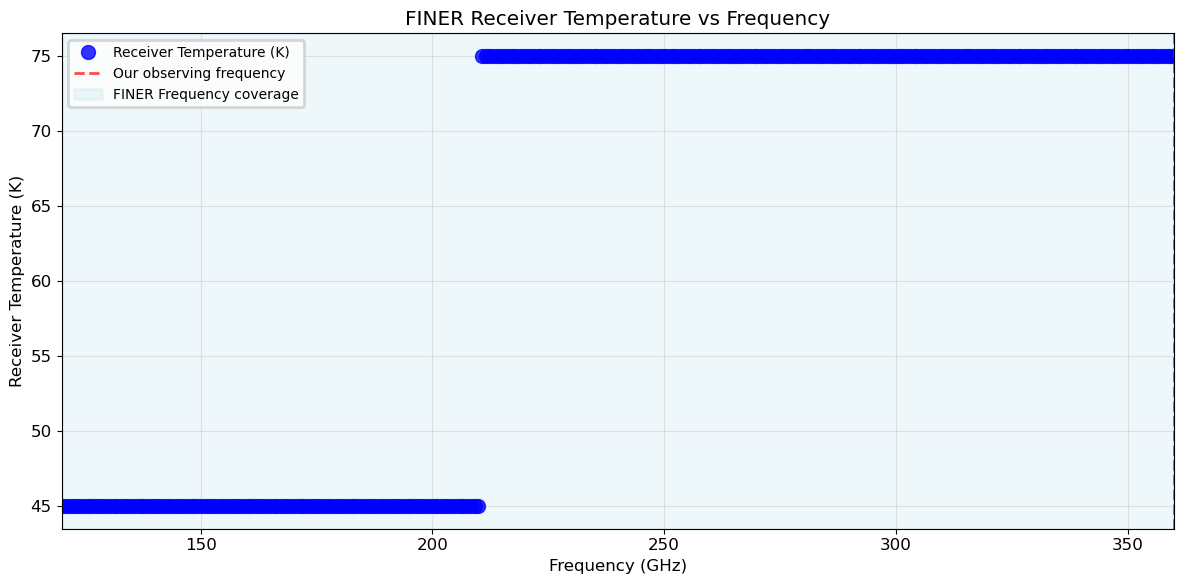

In [60]:
# Filter out None values from t_rx_values for plotting
valid_data = [(freq, t_rx) for freq, t_rx in zip(frequencies, t_rx_values) if t_rx is not None]
valid_frequencies, valid_t_rx = zip(*valid_data) if valid_data else ([], [])

# Plot the receiver temperatures.
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(valid_frequencies, [t.value for t in valid_t_rx], 'o',label = 'Receiver Temperature (K)', color='b', markersize=10, alpha=0.8)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
#draw a box to highlight the operational frequencies of the FINER receiver
ax.axvspan(frequencies[0],frequencies[-1], color='lightblue', alpha=0.2, label='FINER Frequency coverage')

ax.legend()
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Receiver Temperature (K)')
ax.set_title('FINER Receiver Temperature vs Frequency')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## System Temperature Calculation

The instrument module calculates the system temperature using the following equation:

$$    T_{sys} = \frac{1}{\eta_{eff} \mathfrak{t}} \times [T_{rx} + (\eta_{eff} T_{sky}) + (1-\eta_{eff}) T_{amb}]$$


It includes contributions from:
- Receiver temperature (T_rx)
- Sky temperature (T_sky)
- Ambient Temperature (T_amb)
- Telescope
- Cosmic microwave background

Below, we show plots of the three noise temperature equivalent components of the system temperature: sky, ambient and receiver as a function of frequency. Telescope and CMB contributions are not shown as they are applied consistently across all instruments.

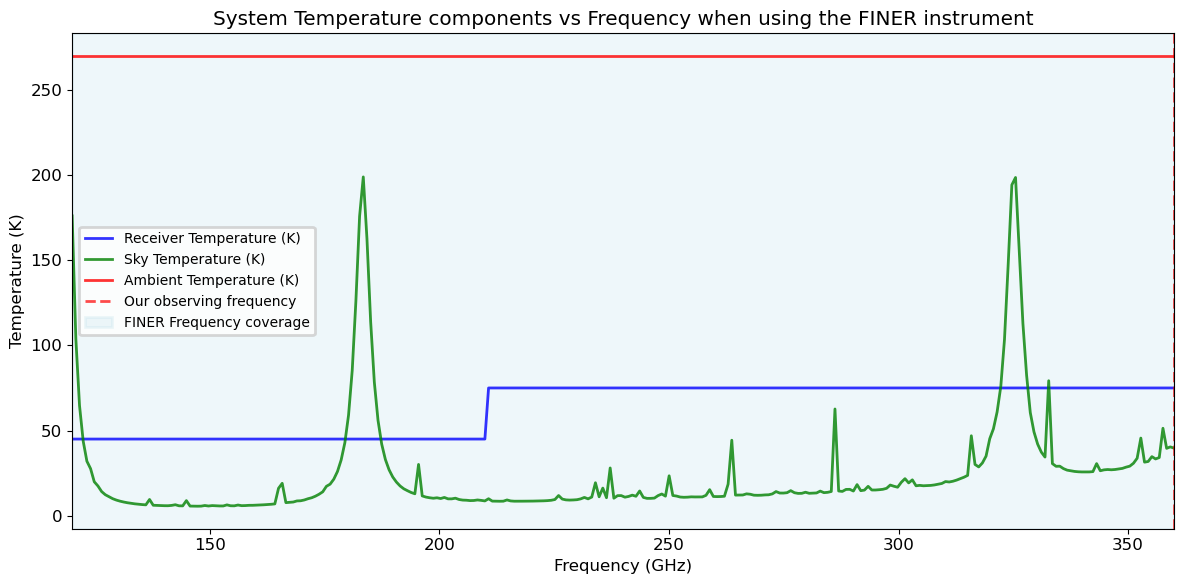

In [61]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(valid_frequencies, [t.value for t in valid_t_rx], '-',label = 'Receiver Temperature (K)', color='b', markersize=10, alpha=0.8)
ax.plot(frequencies, t_sky_contribution, '-',label = 'Sky Temperature (K)', color='g', markersize=10, alpha=0.8)
ax.plot(frequencies, t_amb_contribution, '-',label = 'Ambient Temperature (K)', color='r', markersize=10, alpha=0.8)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
#draw a box to highlight the operational frequencies of the FINER receiver
ax.axvspan(frequencies[0],frequencies[-1], color='lightblue', alpha=0.2, label='FINER Frequency coverage')

ax.legend()
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Temperature (K)')
ax.set_title('System Temperature components vs Frequency when using the FINER instrument')

plt.tight_layout()
plt.show()

## SEFD Calculation

The System Equivalent Flux Density (SEFD) characterises the sensitivity of the telescope system. The system temperatures derived in each of the instrument modules are used to calculate the overal SEFD for the telescope, which is then used to calculate the sensitivity.

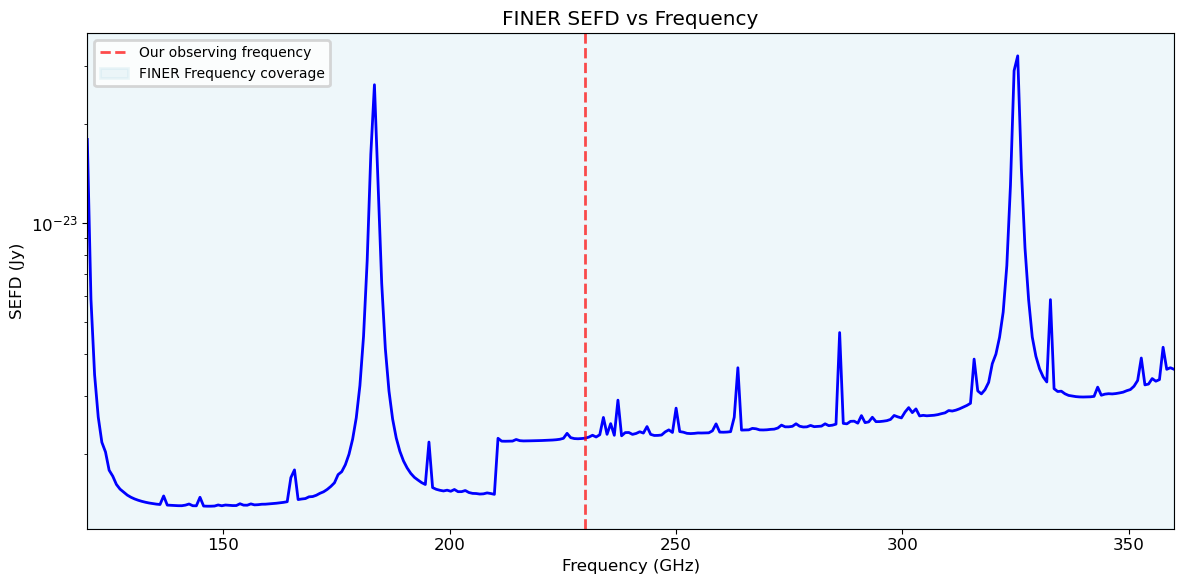

In [47]:
# Plot SEFD as a function of frequency
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(frequencies, sefd_values, 'b-', linewidth=2)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
#draw a box to highlight the operational frequencies of the FINER receiver
ax.axvspan(frequencies[0],frequencies[-1], color='lightblue', alpha=0.2, label='FINER Frequency coverage')

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('SEFD (Jy)')
ax.set_yscale('log')
ax.set_title('FINER SEFD vs Frequency')

ax.legend()
plt.tight_layout()
plt.show()

## Sensitivity Calculation

With all of those underlying values calculated and plotted, now let's calculate the RMS sensitivity of the telescope when using the FINER instrument.

Sensitivity for an integration time of 30.0 min


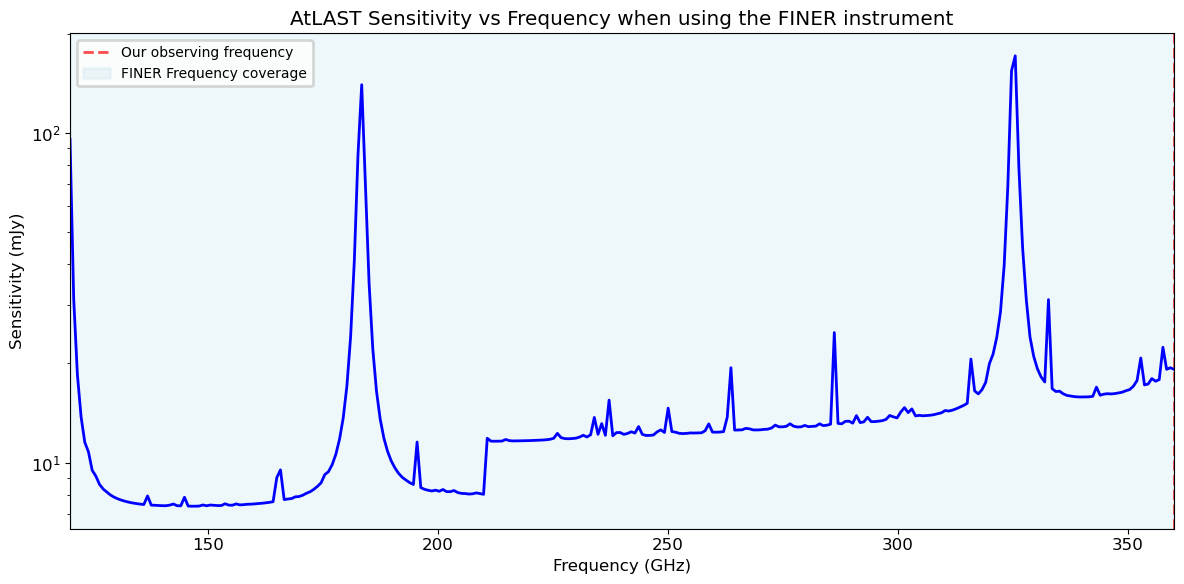

In [62]:
# Remind ourselves of the integration time used for this calculation
print(f"Sensitivity for an integration time of {calculator.user_input.t_int}")

# Show calculated sensitivity
fig, ax = plt.subplots(figsize=(12, 6))
# extract the astropy quantity sensitivities from the sensitivity array calculated above
ax.plot(frequencies, [q.to("mJy").value for q in sensitivity], 'b-', linewidth=2)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
#draw a box to highlight the operational frequencies of the FINER receiver
ax.axvspan(frequencies[0],frequencies[-1], color='lightblue', alpha=0.2, label='FINER Frequency coverage')

ax.set_yscale('log')
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Sensitivity (mJy)')
ax.set_title('AtLAST Sensitivity vs Frequency when using the FINER instrument')

ax.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook has demonstrated the key capabilities of the AtLAST Sensitivity Calculator for the FINER instrument:

1. **Instrument Selection**: Verified automatic selection and demonstrated explicit instrument setting
2. **Frequency Coverage**: Explored FINER's 120-360 GHz range
3. **Atmospheric Effects**: Analysed transmission and emission across the FINER operating frequency ranges
4. **System Performance**: Calculated system temperature, its components, and the overall SEFD
5. **Sensitivity Predictions**: Evaluated spectral line sensitivities across the FINER frequency range